In [41]:
import os

all_files = [
    os.path.join(dirname, filename)
    for dirname, _, filenames in os.walk('/kaggle/input')
    for filename in filenames
]

### Import Necessary Libraries

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow as tf; tf.keras.utils.set_random_seed(42)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [43]:
import os
from PIL import Image

def check_data_quality(directory):
    corrupted = []
    total = 0
    class_counts = {}

    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue
        count = 0
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            total += 1
            count += 1
            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                corrupted.append(fpath)
        class_counts[class_name] = count

    print(f"Directory: {directory}")
    print(f"Total images: {total}")
    print(f"Corrupted images: {len(corrupted)}")
    print(f"Class distribution:")
    for cls, cnt in sorted(class_counts.items()):
        print(f"  {cls}: {cnt}")
    if corrupted:
        print(f"\nCorrupted files:")
        for f in corrupted:
            print(f"  {f}")
    return corrupted

print("=== TRAINING DATA ===")
check_data_quality('/kaggle/input/fer2013/train')
print("\n=== TEST DATA ===")
check_data_quality('/kaggle/input/fer2013/test')

=== TRAINING DATA ===
Directory: /kaggle/input/fer2013/train
Total images: 28709
Corrupted images: 0
Class distribution:
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171

=== TEST DATA ===
Directory: /kaggle/input/fer2013/test
Total images: 7178
Corrupted images: 0
Class distribution:
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831


[]

### Prepare Data Generators for Image Processing

In [44]:
img_size = (48, 48)
batch_size = 64
train_dir = '/kaggle/input/fer2013/train'
test_dir = '/kaggle/input/fer2013/test'

train_dg = ImageDataGenerator(rescale=1./255, validation_split=0.1)

train_generator = train_dg.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_dg.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_dg = ImageDataGenerator(rescale=1./255)

test_generator = test_dg.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [45]:
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Training samples: 25841
Validation samples: 2868
Test samples: 7178


### Visualize Sample Image with Labels

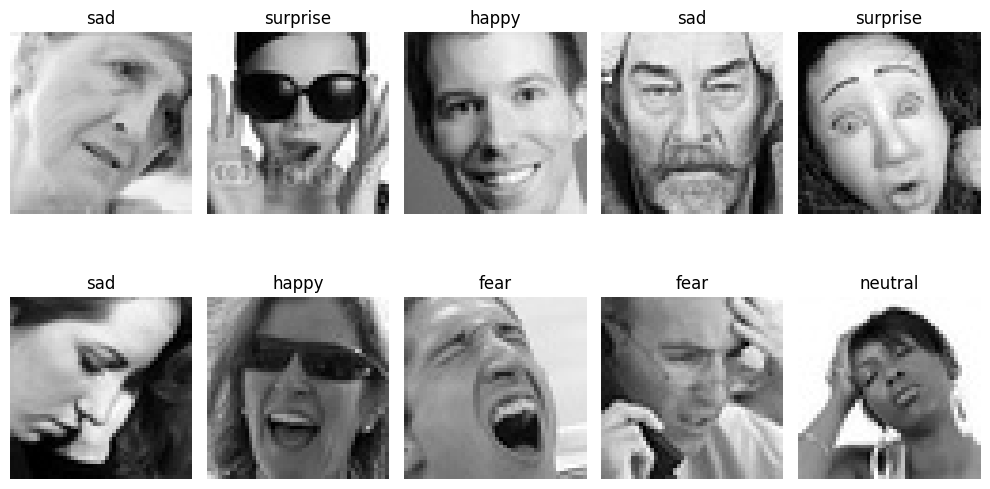

In [46]:
class_names = list(train_generator.class_indices.keys())

def show_samples(generator):
    images, labels = next(generator)
    plt.figure(figsize=(10, 6))
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].reshape(48, 48), cmap="gray")
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    
show_samples(train_generator)

### Data Augmentation - Achieve Image Generilization and Reduce Overfitting

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (48, 48)
batch_size = 64

train_dg = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_dg = ImageDataGenerator(rescale=1./255)

In [48]:
train_generator = train_dg.flow_from_directory(
    '/kaggle/input/fer2013/train',
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

val_generator = train_dg.flow_from_directory(
    '/kaggle/input/fer2013/train',
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_dg.flow_from_directory(
    '/kaggle/input/fer2013/test',
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


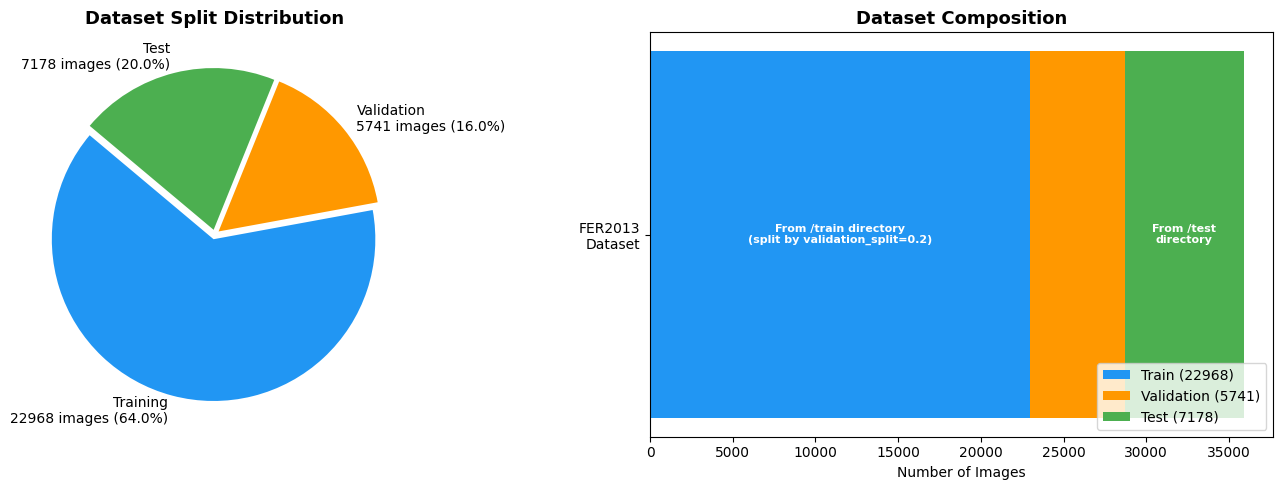


Data Split Summary:
  Training set:    22968 images (64.0%)
  Validation set:  5741 images (16.0%)
  Test set:        7178 images (20.0%)
  Total:           35887 images

Source:
  /kaggle/input/fer2013/train → Split into Train + Validation
  /kaggle/input/fer2013/test  → Used as Test for Unseen Images


In [49]:
import matplotlib.patches as mpatches

train_count = train_generator.samples
val_count = val_generator.samples
test_count = test_generator.samples
total = train_count + val_count + test_count

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Pie Chart ---
sizes = [train_count, val_count, test_count]
labels_pie = [
    f'Training\n{train_count} images ({train_count/total*100:.1f}%)',
    f'Validation\n{val_count} images ({val_count/total*100:.1f}%)',
    f'Test\n{test_count} images ({test_count/total*100:.1f}%)'
]
colors = ['#2196F3', '#FF9800', '#4CAF50']
explode = (0.03, 0.03, 0.03)
axes[0].pie(sizes, labels=labels_pie, colors=colors, explode=explode,
            autopct='', startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Dataset Split Distribution', fontsize=13, fontweight='bold')

# --- Stacked Bar showing source ---
bar_width = 0.5
axes[1].barh(['FER2013\nDataset'], [train_count], color='#2196F3', label=f'Train ({train_count})')
axes[1].barh(['FER2013\nDataset'], [val_count], left=[train_count], color='#FF9800',
             label=f'Validation ({val_count})')
axes[1].barh(['FER2013\nDataset'], [test_count], left=[train_count + val_count], color='#4CAF50',
             label=f'Test ({test_count})')
axes[1].set_xlabel('Number of Images')
axes[1].set_title('Dataset Composition', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

# Add annotation showing origin
axes[1].annotate('From /train directory\n(split by validation_split=0.2)',
                 xy=(train_count/2, 0), fontsize=8, ha='center', va='center', color='white',
                 fontweight='bold')
axes[1].annotate('From /test\ndirectory',
                 xy=(train_count + val_count + test_count/2, 0), fontsize=8,
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('data_split_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nData Split Summary:")
print(f"  Training set:    {train_count} images ({train_count/total*100:.1f}%)")
print(f"  Validation set:  {val_count} images ({val_count/total*100:.1f}%)")
print(f"  Test set:        {test_count} images ({test_count/total*100:.1f}%)")
print(f"  Total:           {total} images")
print(f"\nSource:")
print(f"  /kaggle/input/fer2013/train → Split into Train + Validation")
print(f"  /kaggle/input/fer2013/test  → Used as Test for Unseen Images")

In [50]:
print("VALIDATION SET composition:")
print(f"  Source directory: {val_generator.directory}")
print(f"  Total images: {val_generator.samples}")
print(f"  Class distribution:")
for cls, idx in val_generator.class_indices.items():
    count = list(val_generator.classes).count(idx)
    print(f"    {cls}: {count}")

print(f"\nTEST SET composition:")
print(f"  Source directory: {test_generator.directory}")
print(f"  Total images: {test_generator.samples}")
print(f"  Class distribution:")
for cls, idx in test_generator.class_indices.items():
    count = list(test_generator.classes).count(idx)
    print(f"    {cls}: {count}")

# Verify no overlap
val_files = set(val_generator.filepaths)
test_files = set(test_generator.filepaths)
overlap = val_files.intersection(test_files)
print(f"\nOverlap check: {len(overlap)} files in common (should be 0)")

VALIDATION SET composition:
  Source directory: /kaggle/input/fer2013/train
  Total images: 5741
  Class distribution:
    angry: 799
    disgust: 87
    fear: 819
    happy: 1443
    neutral: 993
    sad: 966
    surprise: 634

TEST SET composition:
  Source directory: /kaggle/input/fer2013/test
  Total images: 7178
  Class distribution:
    angry: 958
    disgust: 111
    fear: 1024
    happy: 1774
    neutral: 1233
    sad: 1247
    surprise: 831

Overlap check: 0 files in common (should be 0)


### Training Callbacks: Training Optimization & Overfitting Preventation

In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',     
    factor=0.2,            
    patience=4,            
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

### Train Model

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization

input_shape = (48, 48, 1)

model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), activation='relu', input_shape=input_shape, padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,510,215 (13.39 MB)

 Trainable params: 3,507,911 (13.38 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [53]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

In [55]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=55,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/55


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 61s 135ms/step - accuracy: 0.2376 - loss: 2.3008 - val_accuracy: 0.1855 - val_loss: 2.1537 - learning_rate: 0.0010
Epoch 2/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.3693 - loss: 1.6471 - val_accuracy: 0.2353 - val_loss: 1.9053 - learning_rate: 0.0010
Epoch 3/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.4764 - loss: 1.3747 - val_accuracy: 0.4581 - val_loss: 1.4560 - learning_rate: 0.0010
Epoch 4/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.4971 - loss: 1.3126 - val_accuracy: 0.5186 - val_loss: 1.2607 - learning_rate: 0.0010
Epoch 5/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.5269 - loss: 1.2463 - val_accuracy: 0.4830 - val_loss: 1.3708 - learning_rate: 0.0010
Epoch 6/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.5417 - loss: 1.2106 - val_accuracy: 0.5454 - val_loss: 1.2090 - learning_rate: 0.0010
Epoch 7/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.5652 - loss:

In [56]:
print("HYPERPARAMETER AUDIT")
print("=" * 60)
print(f"Batch size:          {batch_size}")
print(f"Image size:          {img_size}")
print(f"Validation split:    0.2 (20%)")
print(f"Max epochs:          55")
print(f"Optimizer:           Adam (default lr=0.001)")
print(f"Loss:                categorical_crossentropy")
print()
print("Data Augmentation:")
print(f"  rotation_range:    20°")
print(f"  zoom_range:        0.2")
print(f"  horizontal_flip:   True")
print(f"  rescale:           1./255")
print()
print("Callbacks (both monitor val_loss):")
print(f"  EarlyStopping:     patience=8, restore_best_weights=True")
print(f"  ReduceLROnPlateau: patience=4, factor=0.2")
print()
print("Architecture:")
print(f"  Conv blocks:       3 (64→128→256 filters)")
print(f"  Kernel size:       3×3 (all layers)")
print(f"  Dropout (conv):    0.25")
print(f"  Dense layer:       256 units")
print(f"  Dropout (FC):      0.5")
print(f"  Output:            7 (softmax)")
print(f"  BatchNorm:         After every Conv2D and Dense layer")

HYPERPARAMETER AUDIT
Batch size:          64
Image size:          (48, 48)
Validation split:    0.2 (20%)
Max epochs:          55
Optimizer:           Adam (default lr=0.001)
Loss:                categorical_crossentropy

Data Augmentation:
  rotation_range:    20°
  zoom_range:        0.2
  horizontal_flip:   True
  rescale:           1./255

Callbacks (both monitor val_loss):
  EarlyStopping:     patience=8, restore_best_weights=True
  ReduceLROnPlateau: patience=4, factor=0.2

Architecture:
  Conv blocks:       3 (64→128→256 filters)
  Kernel size:       3×3 (all layers)
  Dropout (conv):    0.25
  Dense layer:       256 units
  Dropout (FC):      0.5
  Output:            7 (softmax)
  BatchNorm:         After every Conv2D and Dense layer


### Visualizing Training Performance

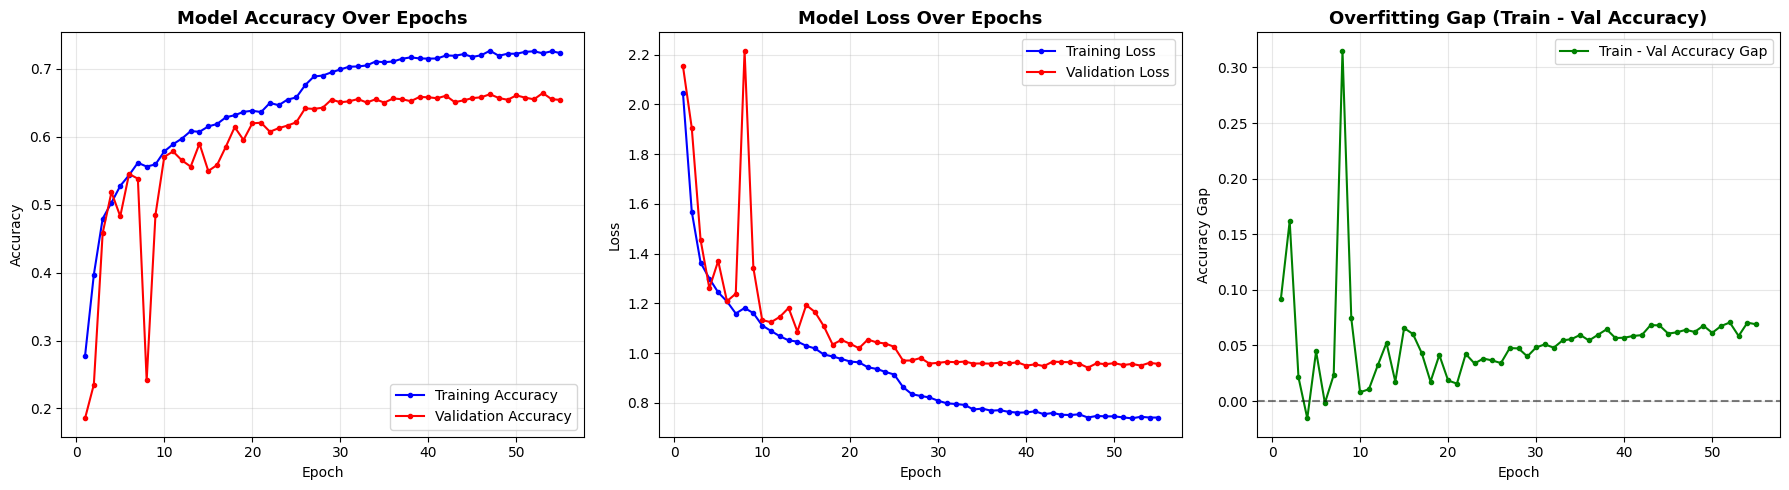


TRAINING SUMMARY
Total Epochs Run:       55
Best Epoch (lowest val_loss): 47
Final Train Accuracy:   0.7234
Final Val Accuracy:     0.6544
Final Train Loss:       0.7412
Final Val Loss:         0.9570


In [57]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Accuracy ---
axes[0].plot(epochs_range, history.history['accuracy'], 'b-o', markersize=3, label='Training Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], 'r-o', markersize=3, label='Validation Accuracy')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# --- Loss ---
axes[1].plot(epochs_range, history.history['loss'], 'b-o', markersize=3, label='Training Loss')
axes[1].plot(epochs_range, history.history['val_loss'], 'r-o', markersize=3, label='Validation Loss')
axes[1].set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# --- Accuracy Gap (Overfitting Indicator) ---
train_acc = np.array(history.history['accuracy'])
val_acc = np.array(history.history['val_accuracy'])
gap = train_acc - val_acc
axes[2].plot(epochs_range, gap, 'g-o', markersize=3, label='Train - Val Accuracy Gap')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_title('Overfitting Gap (Train - Val Accuracy)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy Gap')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final summary
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\n{'='*50}")
print(f"TRAINING SUMMARY")
print(f"{'='*50}")
print(f"Total Epochs Run:       {len(history.history['accuracy'])}")
print(f"Best Epoch (lowest val_loss): {best_epoch}")
print(f"Final Train Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy:     {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Train Loss:       {history.history['loss'][-1]:.4f}")
print(f"Final Val Loss:         {history.history['val_loss'][-1]:.4f}")

### Confusion Matrix

113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step


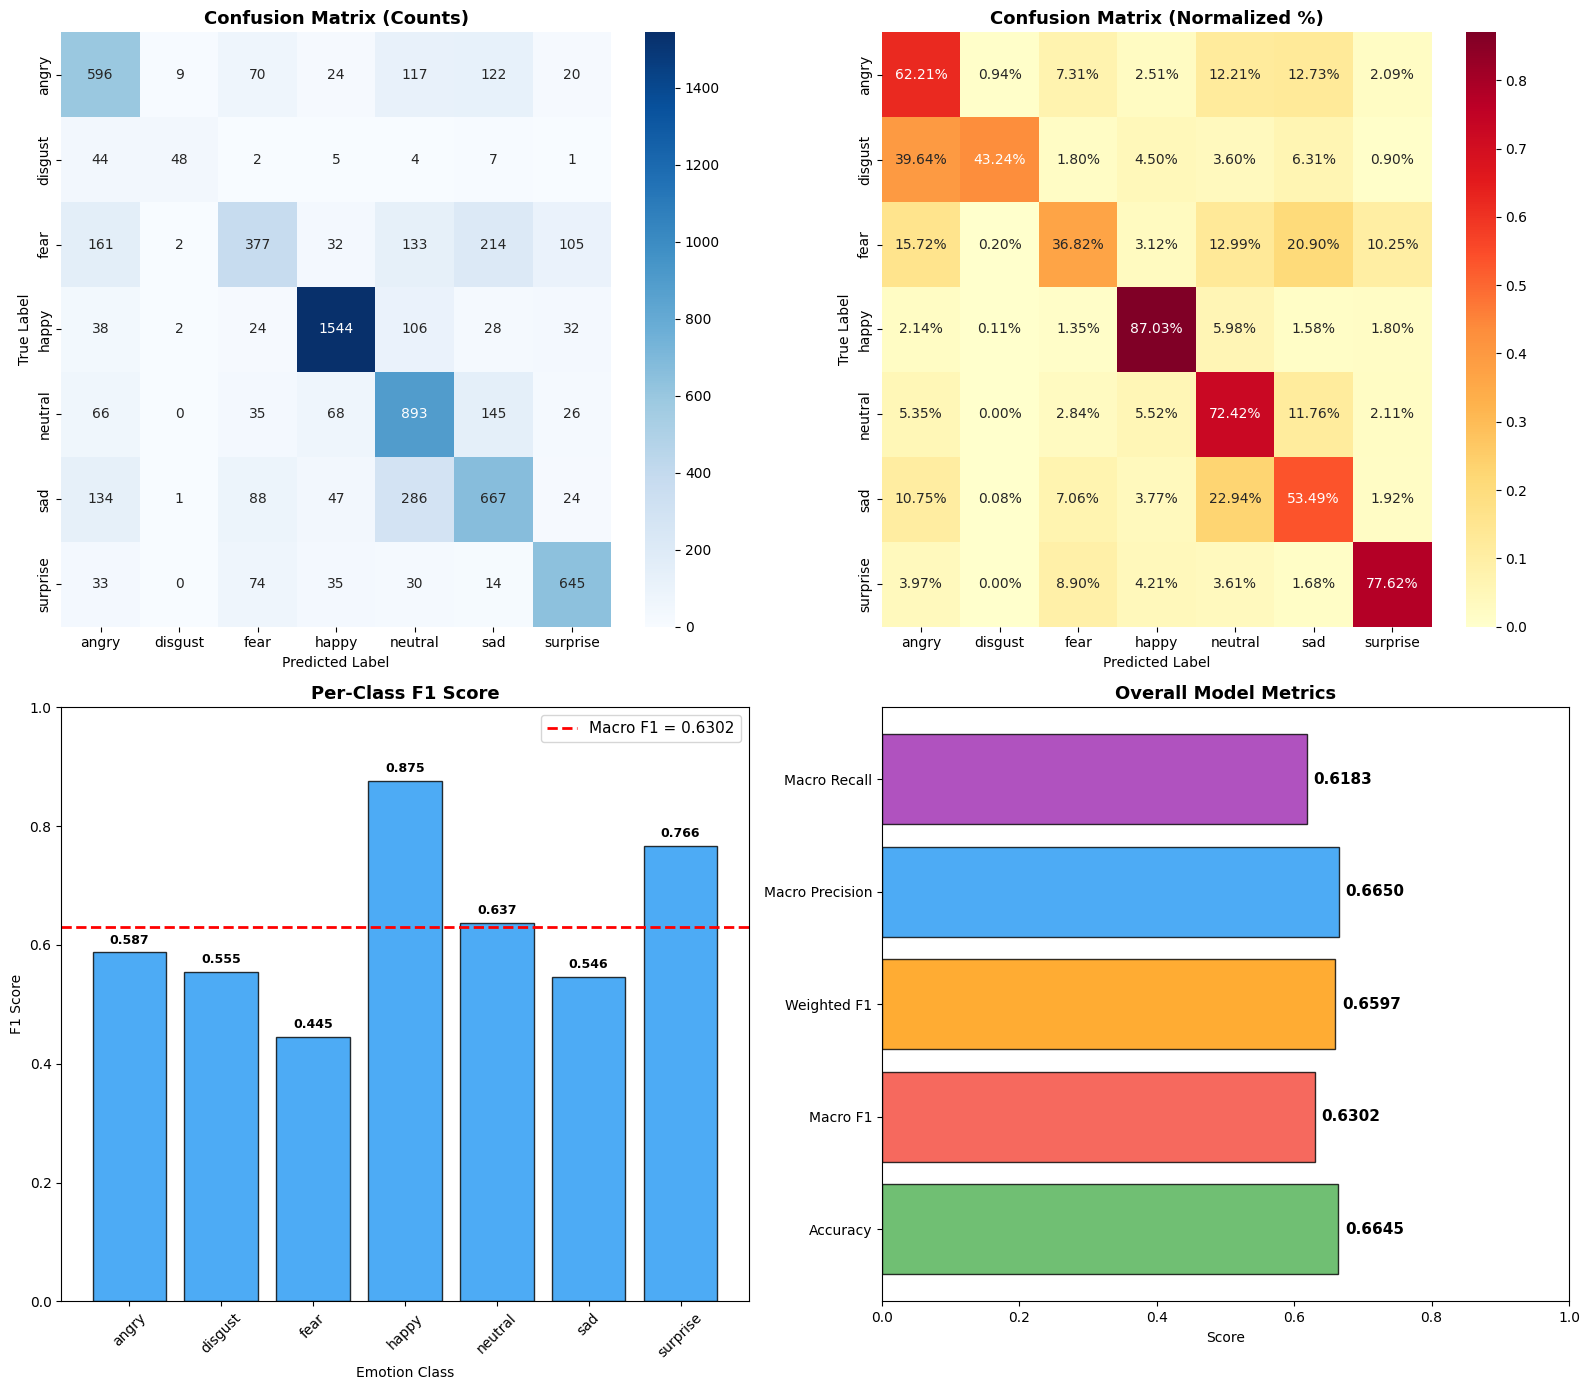


FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.5560    0.6221    0.5872       958
     disgust     0.7742    0.4324    0.5549       111
        fear     0.5627    0.3682    0.4451      1024
       happy     0.8798    0.8703    0.8750      1774
     neutral     0.5692    0.7242    0.6374      1233
         sad     0.5572    0.5349    0.5458      1247
    surprise     0.7562    0.7762    0.7660       831

    accuracy                         0.6645      7178
   macro avg     0.6650    0.6183    0.6302      7178
weighted avg     0.6660    0.6645    0.6597      7178


Overall Accuracy:    0.6645
Macro F1 Score:      0.6302
Weighted F1 Score:   0.6597
Macro Precision:     0.6650
Macro Recall:        0.6183


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, accuracy_score, precision_score, recall_score
)

# --- Compute Metrics ---
test_generator.reset()
pred_probs = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

overall_acc = accuracy_score(true_classes, pred_classes)
macro_f1 = f1_score(true_classes, pred_classes, average='macro')
weighted_f1 = f1_score(true_classes, pred_classes, average='weighted')
macro_precision = precision_score(true_classes, pred_classes, average='macro')
macro_recall = recall_score(true_classes, pred_classes, average='macro')

# Per-class F1
per_class_f1 = f1_score(true_classes, pred_classes, average=None)
per_class_acc = []
for i in range(len(class_labels)):
    mask = true_classes == i
    per_class_acc.append(accuracy_score(true_classes[mask], pred_classes[mask]))

cm = confusion_matrix(true_classes, pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# --- Create Figure with 4 subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# (1) Confusion Matrix — Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# (2) Confusion Matrix — Normalized (%)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# (3) Per-Class F1 Score Bar Chart
bars = axes[1, 0].bar(class_labels, per_class_f1, color='#2196F3', edgecolor='black', alpha=0.8)
axes[1, 0].axhline(y=macro_f1, color='red', linestyle='--', linewidth=2, label=f'Macro F1 = {macro_f1:.4f}')
axes[1, 0].set_title('Per-Class F1 Score', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Emotion Class')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend(fontsize=11)
axes[1, 0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, per_class_f1):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# (4) Overall Metrics Summary
metrics_names = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro Precision', 'Macro Recall']
metrics_values = [overall_acc, macro_f1, weighted_f1, macro_precision, macro_recall]
colors_bar = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']
bars2 = axes[1, 1].barh(metrics_names, metrics_values, color=colors_bar, edgecolor='black', alpha=0.8)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_title('Overall Model Metrics', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Score')
for bar, val in zip(bars2, metrics_values):
    axes[1, 1].text(val + 0.01, bar.get_y() + bar.get_height()/2.,
                     f'{val:.4f}', ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('comprehensive_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print Full Classification Report ---
print("\n" + "=" * 60)
print("FULL CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(true_classes, pred_classes, target_names=class_labels, digits=4))

print(f"\nOverall Accuracy:    {overall_acc:.4f}")
print(f"Macro F1 Score:      {macro_f1:.4f}")
print(f"Weighted F1 Score:   {weighted_f1:.4f}")
print(f"Macro Precision:     {macro_precision:.4f}")
print(f"Macro Recall:        {macro_recall:.4f}")

In [59]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.6235 - loss: 1.0305
Test Accuracy: 0.6645
Test Loss: 0.9347


### Predictions Made

In [60]:
import numpy as np

pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step


### Predicting 200 Random Images

Image source: /kaggle/input/fer2013/test
Total test images available: 7178
This is the TEST set (same as evaluation split): True



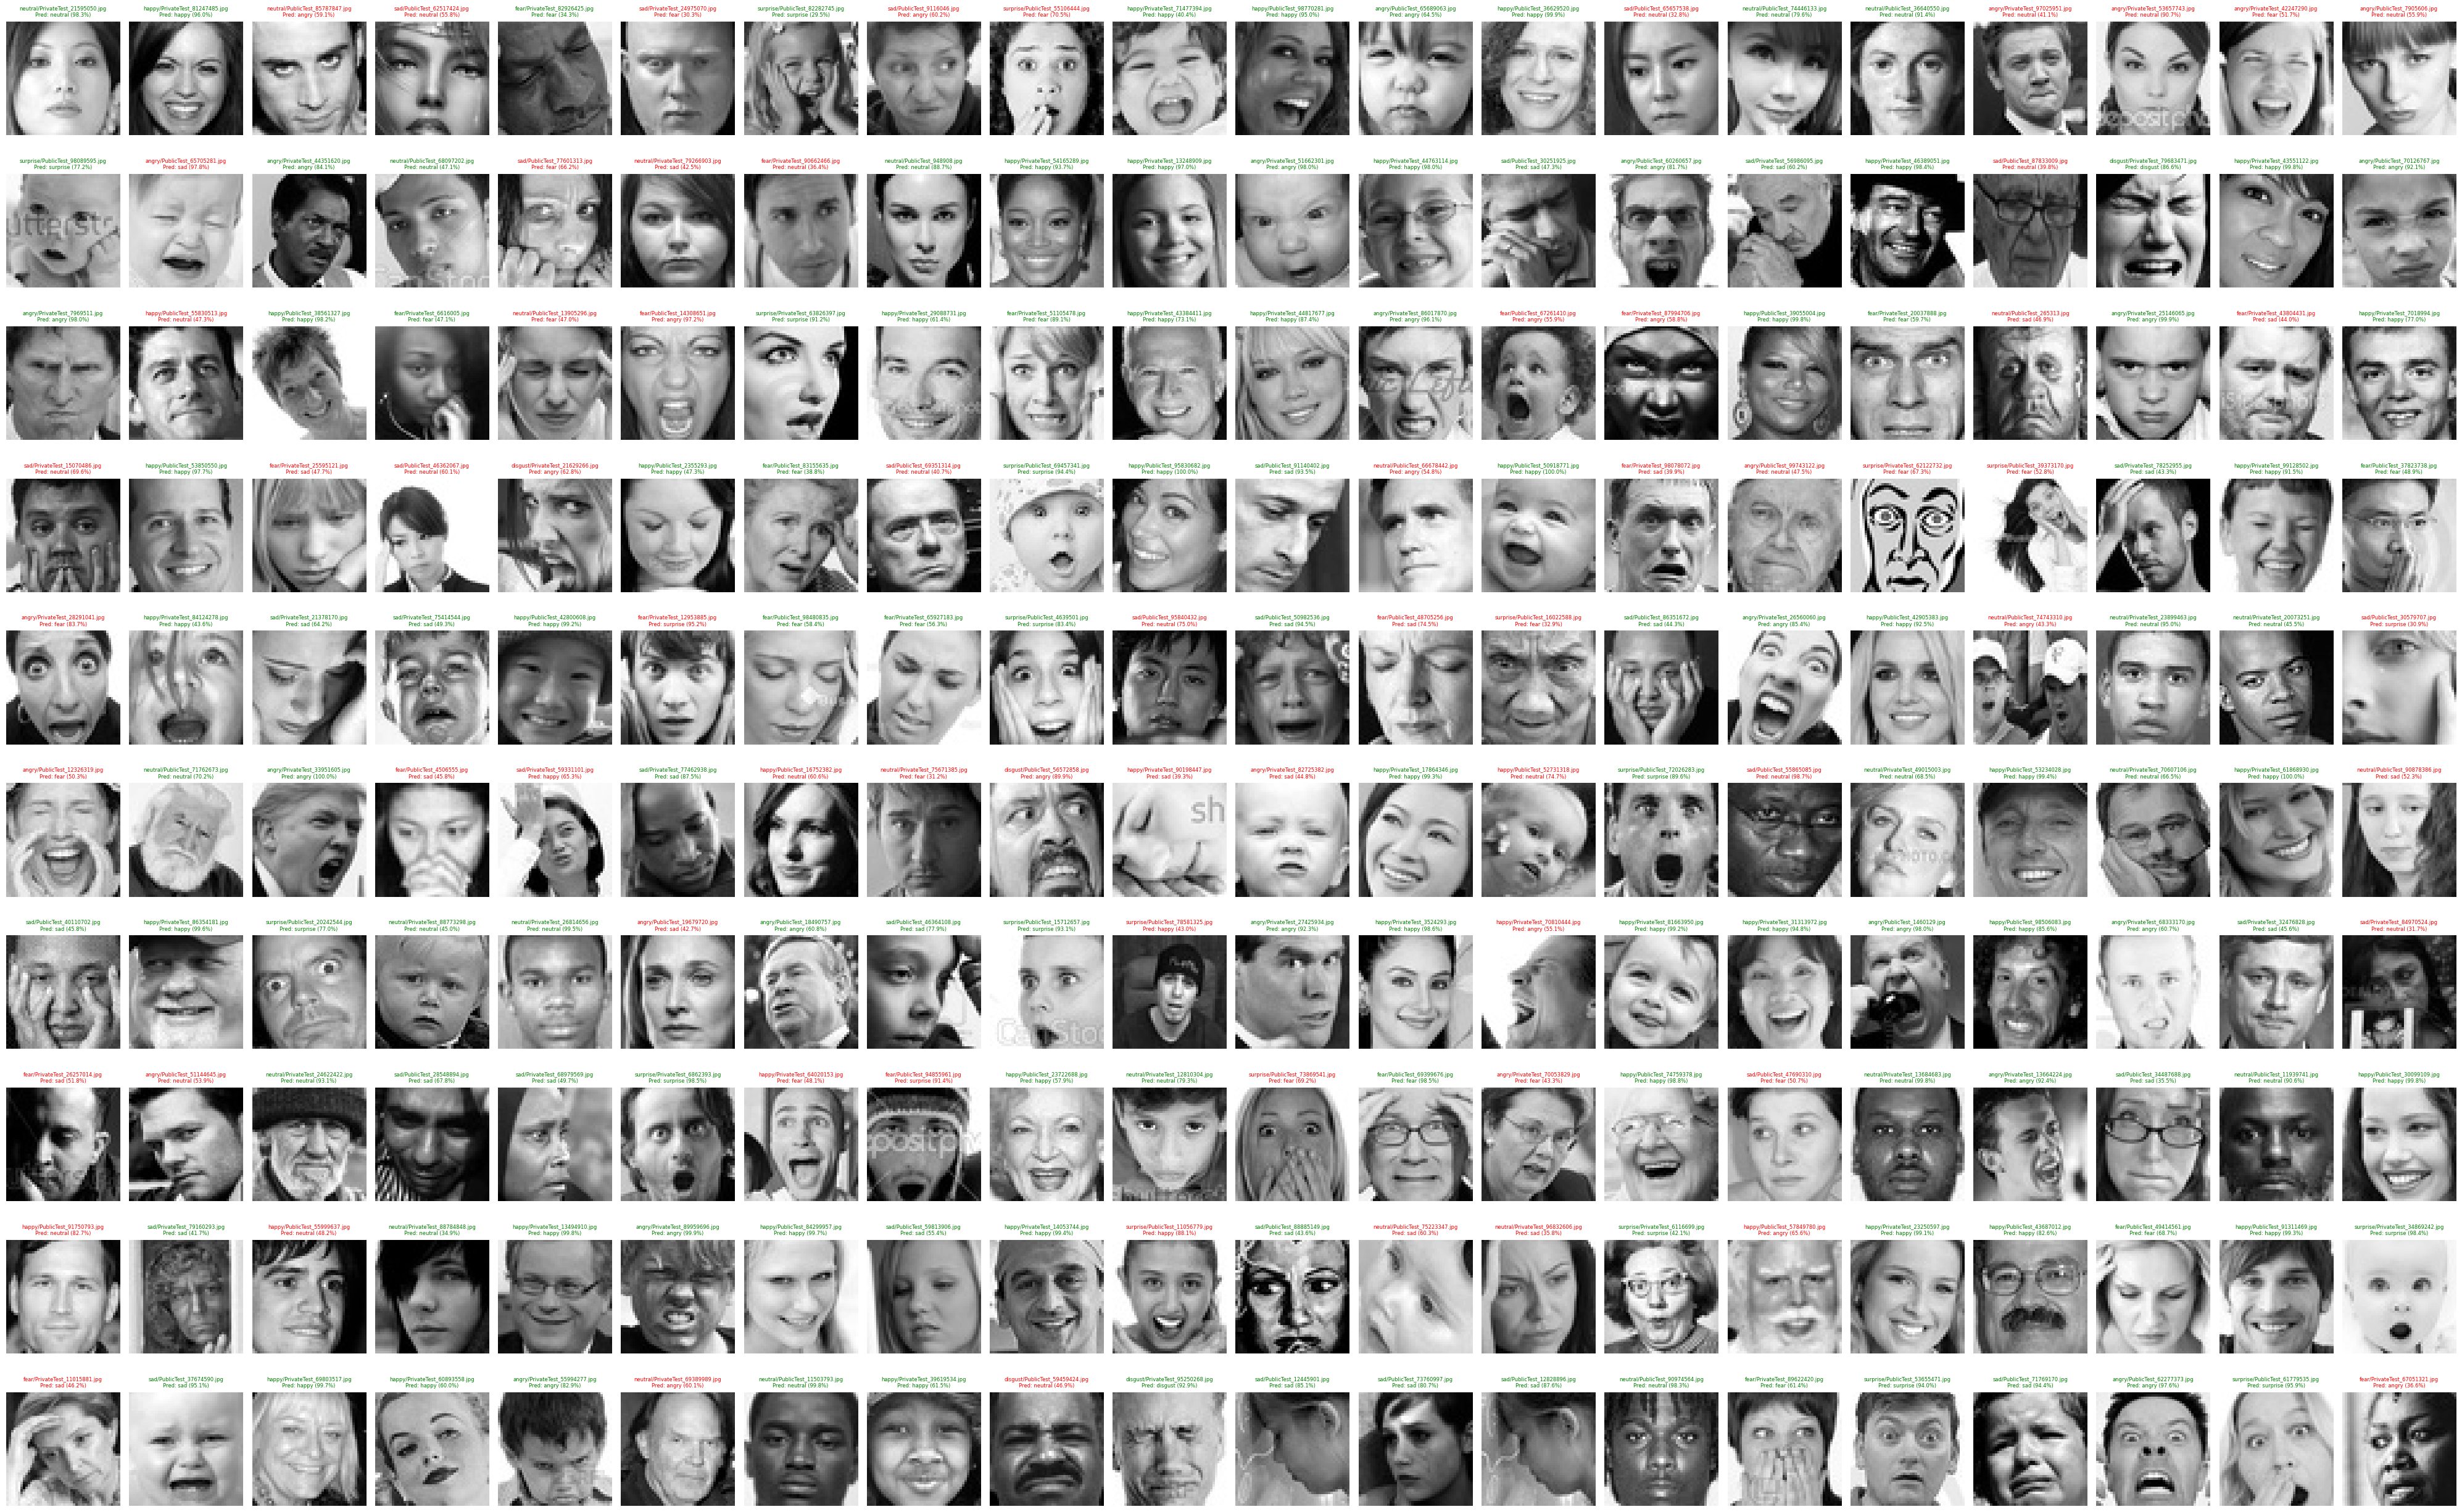


Correctly Predicted: 129 / 200 (64.5%)
Unique images sampled: 200
Source: test_generator (/kaggle/input/fer2013/test)


In [61]:
filenames = test_generator.filepaths

# Verify source
print(f"Image source: {os.path.dirname(os.path.dirname(filenames[0]))}")
print(f"Total test images available: {len(filenames)}")
print(f"This is the TEST set (same as evaluation split): True\n")

# Use np.random.choice WITHOUT replacement to avoid duplicates
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(filenames), size=200, replace=False)

plt.figure(figsize=(40, 25))
correct_count = 0

for i, index in enumerate(indices):
    img_path = filenames[index]
    img = plt.imread(img_path)

    class_name = os.path.basename(os.path.dirname(img_path))
    filename = os.path.basename(img_path)

    true_label = class_labels[true_classes[index]]
    pred_label = class_labels[pred_classes[index]]
    confidence = np.max(pred_probs[index]) * 100

    if pred_label == true_label:
        correct_count += 1

    plt.subplot(10, 20, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    title_color = 'green' if pred_label == true_label else 'red'
    plt.title(f'{class_name}/{filename}\nPred: {pred_label} ({confidence:.1f}%)',
              fontsize=6, color=title_color)

plt.tight_layout()
plt.savefig('200_test_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nCorrectly Predicted: {correct_count} / 200 ({correct_count/200*100:.1f}%)')
print(f'Unique images sampled: {len(set(indices))}')
print(f'Source: test_generator (/kaggle/input/fer2013/test)')

In [62]:
from sklearn.metrics import classification_report; print(classification_report(true_classes, pred_classes, target_names=class_labels, digits=3, zero_division=0))

              precision    recall  f1-score   support

       angry      0.556     0.622     0.587       958
     disgust      0.774     0.432     0.555       111
        fear      0.563     0.368     0.445      1024
       happy      0.880     0.870     0.875      1774
     neutral      0.569     0.724     0.637      1233
         sad      0.557     0.535     0.546      1247
    surprise      0.756     0.776     0.766       831

    accuracy                          0.665      7178
   macro avg      0.665     0.618     0.630      7178
weighted avg      0.666     0.665     0.660      7178

